In [1]:
from brisc_project.models import get_resnet18
import torch

model = get_resnet18(num_classes=4)

model.load_state_dict(
    torch.load(
        "../models/resnet18_brain_tumor.pth",
        map_location="cpu"
    )
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [2]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

In [3]:
from brisc_project.brisc import get_data_loader

test_loader, classes = get_data_loader(
    "../brain_tumor/brisc2025/classification_task/test",
    batch_size=32
)

In [4]:
from sklearn.metrics import classification_report, confusion_matrix

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

      glioma       0.99      0.63      0.77       254
  meningioma       0.73      0.97      0.83       306
    no_tumor       0.91      0.99      0.95       140
   pituitary       0.99      0.93      0.96       300

    accuracy                           0.87      1000
   macro avg       0.91      0.88      0.88      1000
weighted avg       0.90      0.87      0.87      1000



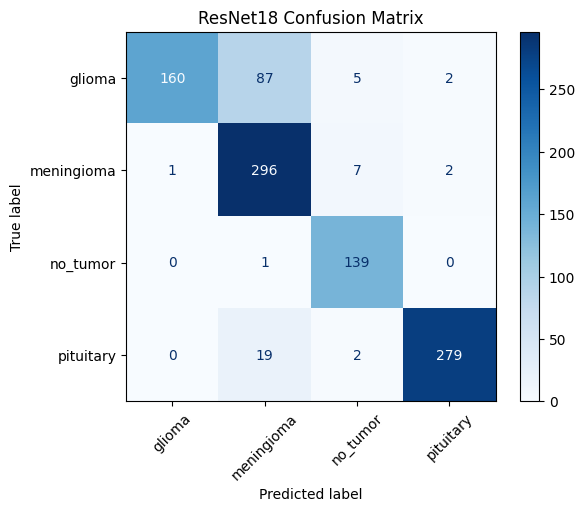

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("ResNet18 Confusion Matrix")
plt.savefig("../assets/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

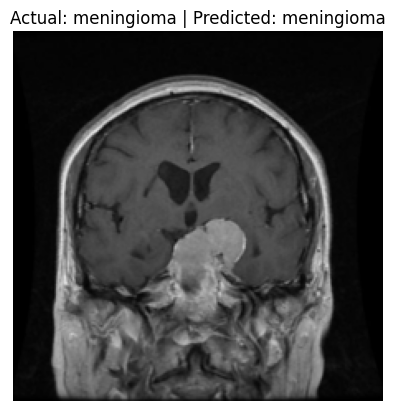

In [6]:
image, label = next(iter(test_loader))

image = image.to(device)

with torch.no_grad():
    output = model(image)
    prediction = output.argmax(dim=1)

plt.imshow(image[0].cpu().permute(1, 2, 0))
plt.title(f"Actual: {classes[label[0]]} | Predicted: {classes[prediction[0]]}")
plt.axis("off")
plt.show()

In [7]:
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.layer4[-1]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [8]:
gradcam_image = image[0].unsqueeze(0)

model.zero_grad()

output = model(gradcam_image)

class_idx = prediction[0].item()
score = output[:, class_idx]

score.backward()

In [9]:
weights = gradients.mean(dim=(2, 3), keepdim=True)

cam = (weights * activations).sum(dim=1).squeeze()
cam = torch.relu(cam)
cam = cam - cam.min()
cam = cam / cam.max()
cam = cam.detach().numpy()

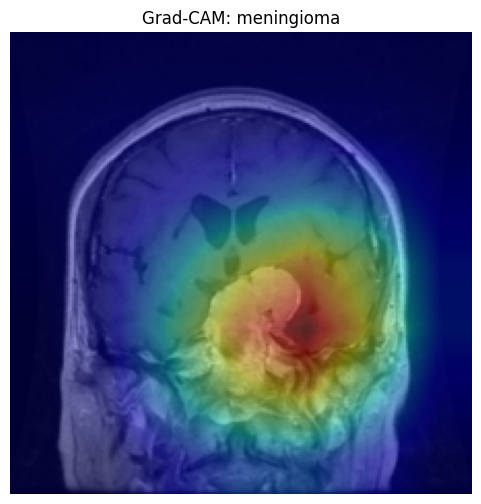

In [10]:
import cv2
import matplotlib.pyplot as plt

img = gradcam_image.squeeze().detach().cpu().permute(1, 2, 0).numpy()

cam_resized = cv2.resize(
    cam,
    (img.shape[1], img.shape[0])
)

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap="gray")
plt.imshow(cam_resized, cmap="jet", alpha=0.4)
plt.title(f"Grad-CAM: {classes[class_idx]}")
plt.axis("off")
plt.show()

C:\Users\ccai2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


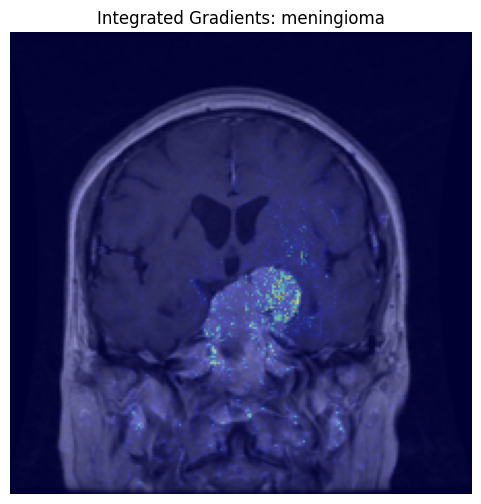

In [11]:
from captum.attr import IntegratedGradients
import numpy as np
import matplotlib.pyplot as plt

ig = IntegratedGradients(model)

target_class = prediction[0].item()

attributions = ig.attribute(
    gradcam_image,
    target=target_class
)

attr = attributions.squeeze().detach().cpu().numpy()
attr = np.mean(np.abs(attr), axis=0)

attr = (attr - attr.min()) / (attr.max() - attr.min())

original_img = gradcam_image.squeeze().detach().cpu().permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(original_img, cmap="gray")
plt.imshow(attr, cmap="jet", alpha=0.4)
plt.title(f"Integrated Gradients: {classes[target_class]}")
plt.axis("off")
plt.show()

## Interpretability Summary

The table below summarizes the average overlap between Grad-CAM heatmaps and the ground-truth segmentation masks across multiple correctly classified tumor images.

In [12]:
import pandas as pd

summary = pd.DataFrame({
    "Method": ["Grad-CAM", "Score-CAM"],
    "Average Dice": [
        0.13689405476491526,
        0.12767593466036212
    ],
    "Average IoU": [
        0.07925318958817511,
        0.07727278736714624
    ]
})

summary

,Method,Average Dice,Average IoU
0,Grad-CAM,0.136894,0.079253
1,Score-CAM,0.127676,0.077273


## Interpretation

Grad-CAM achieved higher Dice and IoU scores than Score-CAM when compared against the ground-truth tumor segmentation masks. While both methods provided visual explanations for model predictions, Grad-CAM showed stronger localization performance on the BRISC 2025 dataset. However, both methods produced relatively low overlap scores, suggesting that accurate classification does not necessarily imply precise localization of tumor regions.